## Computer Vision - Aufgabe 1: Affine Transformation von Bildern

### Einlesen der Bilder

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

image = plt.imread("gletscher.jpg")
image2 = plt.imread("ambassadors.jpg")
image3 = plt.imread("test_30x30.jpg")
image = image.astype(float)
image = image / 255
image2 = image2.astype(float)
image2 = image2 / 255
image3 = image3.astype(float)
image3 = image3 / 255

### Affine Transformation von Bildern mit Koordinatenwechsel

In [31]:
def toggleHand(y, height):
    return height - 1 - y

def affine_transform_handed(image, A, a0, method="nearest", factor=2):
    height, width = image.shape[:2]
    newHeight = height
    newWidth = width
    outputImage = np.zeros((newHeight, newWidth, 3))
    
    invA = np.linalg.inv(A)
    for y_rev in range(newHeight):
        for x_rev in range(newWidth):
            #jeden Pixel hier transformieren
            #1. von links nach rechts
            y_c = toggleHand(y_rev, newHeight)
            x_c = x_rev
            #2. inverse Transformation
            transformedPoint = invA @ (np.array([x_c,y_c]) - a0)
            x_t, y_t = transformedPoint
            #3. von rechts nach links
            y_c2 = toggleHand(y_t, height)
            x_c2 = x_t
            if method=="nearest":
                x_n = int(np.round(x_c2))
                y_n = int(np.round(y_c2))
                if 0 <= x_n < width and 0 <= y_n < height:
                    outputImage[y_rev ,x_rev] = image[y_n,x_n]
                else:
                    outputImage[y_rev, x_rev] = 0
            if method=="billinear":
                if 0 <= x_c2 < width - 1 and 0 <= y_c2 < height - 1:
                    y0 = int(np.floor(y_c2))
                    x0 = int(np.floor(x_c2))
                    N1 = image[y0, x0]
                    N2 = image[y0, x0+1]
                    N3 = image[y0+1, x0]
                    N4 = image[y0+1, x0+1]
                    dx = x_c2 - x0
                    dy = y_c2 - y0
                    outputImage[y_rev, x_rev] = (
                        (1 - dx)*(1 - dy) * N1 +
                        dx*(1 - dy)       * N2 +
                        (1 - dx)*dy       * N3 +
                        dx*dy             * N4
                    )
                else:
                    outputImage[y_rev, x_rev] = 0
    return outputImage
                

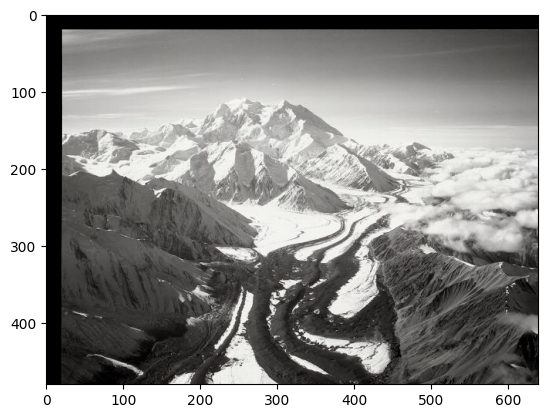

In [42]:
A_simple = np.array([
    [1.0, 0],
    [0, 1.0]]
)
a0 = np.array(
    [20.0, -20.0]
)
a0_simple = np.array(
    [0, 0]
)
transformed_image = affine_transform_handed(image, A_simple, a0, method="billinear", factor=2)
plt.imshow(transformed_image)

In [34]:
def affine_transform(image, A, a0, method="nearest", factor=2):
    height, width = image.shape[:2]
    newHeight = height*factor
    newWidth = width*factor
    outputImage = np.zeros((newHeight, newWidth, 3))
    
    invA = np.linalg.inv(A)
    for y_rev in range(newHeight):
        for x_rev in range(newWidth):
            #2. inverse Transformation
            transformedPoint = invA @ (np.array([x_rev,y_rev]) - a0)
            x_t, y_t = transformedPoint
            if method=="nearest":
                x_n = int(np.round(x_t))
                y_n = int(np.round(y_t))
                if 0 <= x_n < width and 0 <= y_n < height:
                    outputImage[y_rev ,x_rev] = image[y_n,x_n]
                else:
                    outputImage[y_rev, x_rev] = 0
            if method=="billinear":
                if 0 <= x_t < width - 1 and 0 <= y_t < height - 1:
                    y0 = int(np.floor(y_t))
                    x0 = int(np.floor(x_t))
                    N1 = image[y0, x0]
                    N2 = image[y0, x0+1]
                    N3 = image[y0+1, x0]
                    N4 = image[y0+1, x0+1]
                    dx = x_t - x0
                    dy = y_t - y0
                    outputImage[y_rev, x_rev] = (
                        (1 - dx)*(1 - dy) * N1 +
                        dx*(1 - dy)       * N2 +
                        (1 - dx)*dy       * N3 +
                        dx*dy             * N4
                    )
                else:
                    outputImage[y_rev, x_rev] = 0
    return outputImage
                

### Beispiel-Transformationen

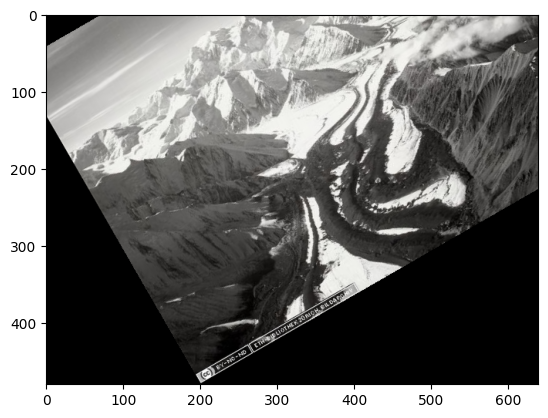

In [41]:
A_simple = np.array([
    [2.0, 0],
    [0, 2.0]]
)
theta = 30
theta_rad = theta / 360 * 2*np.pi

A_rot = np.array([
    [np.cos(theta_rad), -np.sin(theta_rad)],
    [np.sin(theta_rad), np.cos(theta_rad)]
])

a0 = np.array(
    [200.0, 0.0]
)
a0_simple = np.array(
    [0, 0]
)
transformed_image = affine_transform_handed(image, A_rot, a0, method="billinear", factor=2)
plt.imshow(transformed_image)

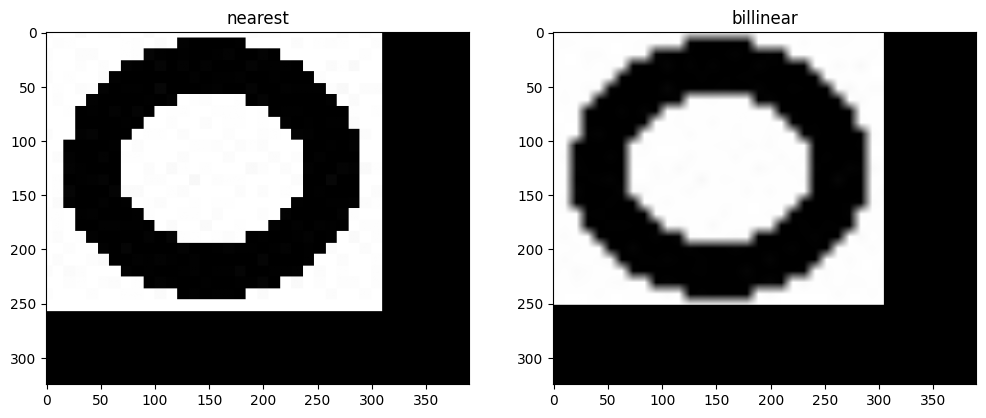

In [40]:
A_ten = np.array([
    [10.5, 0],
    [0, 10.5]]
)
a0_zero = np.array(
    [0, 0]
)
transformed_image = affine_transform(image3, A_ten, a0_zero, method="nearest", factor=13)
transformed_image2 = affine_transform(image3, A_ten, a0_simple, method="billinear", factor=13)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.title("nearest")
plt.imshow(transformed_image)
plt.subplot(1,2,2)
plt.title("billinear")
plt.imshow(transformed_image2)

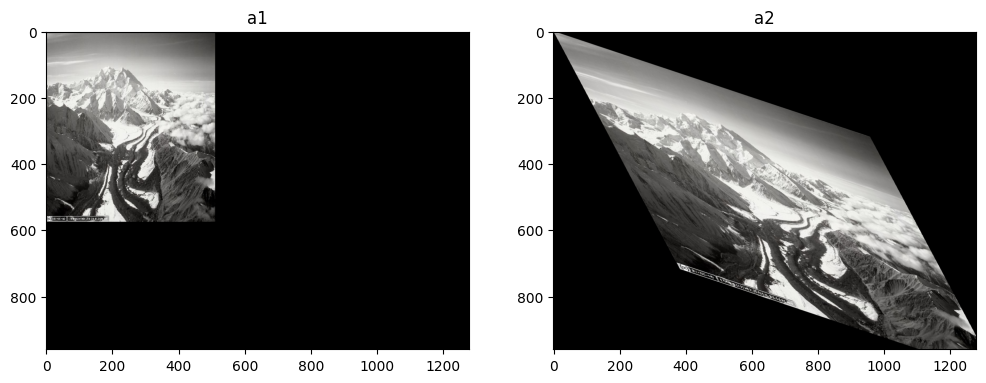

In [16]:
A_1 = np.array([
    [0.8, 0],
    [0, 1.2]]
)
A_2 = np.array([
    [1.5, 0.8],
    [0.5, 1.5]]
)
a0_zero = np.array(
    [0, 0]
)
transformed_image = affine_transform(image, A_1, a0_zero, method="nearest", factor=2)
transformed_image2 = affine_transform(image, A_2, a0_zero, method="nearest", factor=2)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.title("a1")
plt.imshow(transformed_image)
plt.subplot(1,2,2)
plt.title("a2")
plt.imshow(transformed_image2)

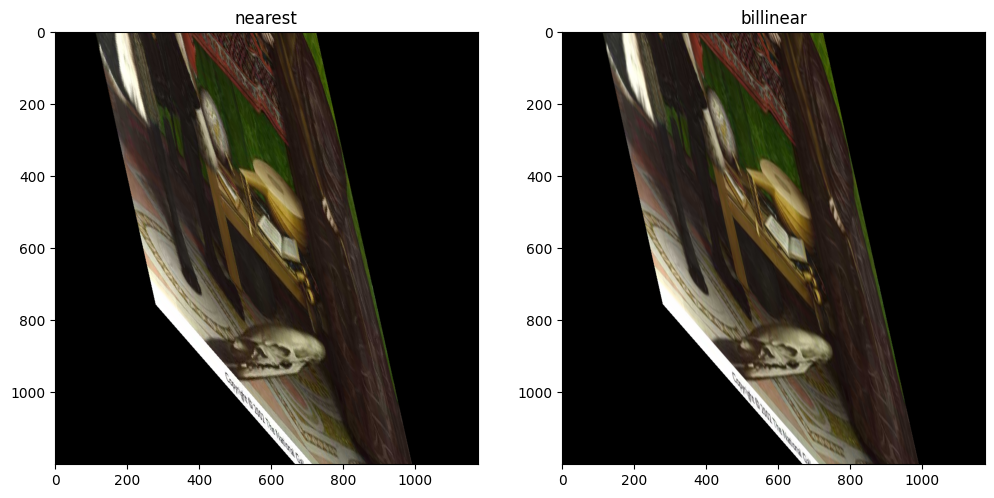

In [52]:
A_3 = np.array([
    [1.4, 0.8],
    [1.6, 3.6]]
)
a0_zero = np.array(
    [-200, -1400]
)
transformed_image4 = affine_transform(image2, A_3, a0_zero, method="nearest", factor=2)
transformed_image5 = affine_transform(image2, A_3, a0_zero, method="billinear", factor=2)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.title("nearest")
plt.imshow(transformed_image4)
plt.subplot(1,2,2)
plt.title("billinear")
plt.imshow(transformed_image5)